=== 1. Business Classification Report ===
              precision    recall  f1-score   support

           0       0.85      0.39      0.53        59
           1       0.65      0.94      0.77        72

    accuracy                           0.69       131
   macro avg       0.75      0.67      0.65       131
weighted avg       0.74      0.69      0.67       131



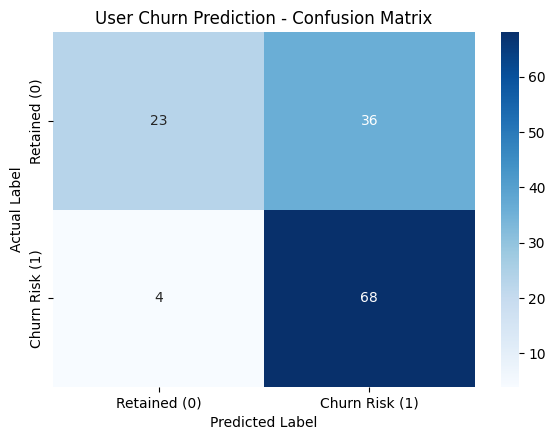

C:\Users\LX\AppData\Local\Temp\ipykernel_30280\1803524321.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="mako")


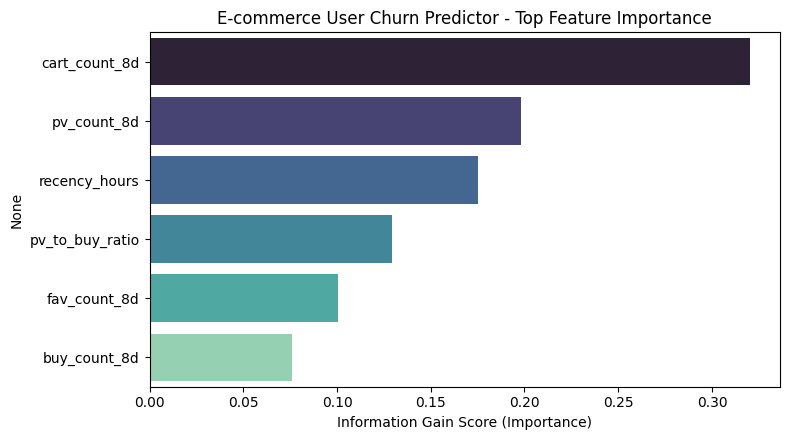

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('user_churn_data.csv')

feature_cols = ['recency_hours', 'pv_count_8d', 'fav_count_8d', 'cart_count_8d', 'buy_count_8d', 'pv_to_buy_ratio']
X = df[feature_cols]
y = df['is_churn']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


rf = RandomForestClassifier(n_estimators=150, max_depth=5, min_samples_leaf=2, random_state=42)
rf.fit(X_train, y_train)


y_prob = rf.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_prob >= 0.40).astype(int)


print("=== 1. Business Classification Report ===")
print(classification_report(y_test, y_pred_adjusted))


plt.figure(figsize=(6, 4.5))
cm = confusion_matrix(y_test, y_pred_adjusted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Retained (0)', 'Churn Risk (1)'], 
            yticklabels=['Retained (0)', 'Churn Risk (1)'])
plt.title('User Churn Prediction - Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


feature_importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 4.5))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="mako")
plt.title("E-commerce User Churn Predictor - Top Feature Importance")
plt.xlabel("Information Gain Score (Importance)")
plt.tight_layout()
plt.show()